# SU(2) Adjoint-Sector Ground State Benchmark

This notebook is a reader for results produced by local Python scripts. It does **not** train the neural network and does **not** run validation tests. Generate the data from the repository root with

```bash
python scripts/run_su2_adjoint_benchmarks.py --output results/su2_adjoint_benchmarks.json
```

and run the unit tests separately with

```bash
python -m pytest tests/test_su2_adjoint.py -q
```

The implemented model is the one-matrix SU(2) adjoint sector with

$$
H=-\frac12\Delta_X+\frac12\omega^2\operatorname{Tr}X^2+g\operatorname{Tr}X^4,
\qquad \operatorname{Tr}(T^aT^b)=\delta^{ab}.
$$

The spectral ansatz is

$$
q_i(\lambda)=\exp[-S_\theta(\lambda)/2] \, \lambda_i,
\qquad
S_\theta(\lambda)=\alpha\sum_i\lambda_i^2+f_\theta\!\left(\sum_i\lambda_i^2\right),
$$

so tracelessness, Weyl covariance, odd parity, and SU(2) adjoint covariance are built into the wavefunction before training.

In [ ]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent

RESULT_PATH = ROOT / "results" / "su2_adjoint_benchmarks.json"
SU3_RESULT_PATH = ROOT / "results" / "su3_adjoint_benchmarks.json"
{"su2": RESULT_PATH, "su3": SU3_RESULT_PATH}


## Load Saved Results

The result file is produced by `scripts/run_su2_adjoint_benchmarks.py`. If this cell fails, rerun that script from the repository root. Keeping the training in a script makes the numerical calculation reproducible and keeps this notebook as an inspection layer.

In [ ]:
if not RESULT_PATH.exists():
    raise FileNotFoundError(
        "Missing benchmark result file. Run from the repository root:\n"
        f"python scripts/run_su2_adjoint_benchmarks.py --output {RESULT_PATH}"
    )

results = json.loads(RESULT_PATH.read_text())
results["metadata"]

## Validation Summary

These booleans are saved by the Python benchmark runner. The actual unit tests live in `tests/test_su2_adjoint.py`; the notebook only displays which checks were used and whether the saved run passed its script-level thresholds.

In [ ]:
results["validation_summary"]

## Exact Harmonic Benchmark

For `g=0`, the exact lowest adjoint-sector energy is

$$
E_{\rm adj,0}=\frac{\omega}{2}(N^2-1)+\omega,
$$

so for SU(2) and \(\omega=1\), the target is \(E=5/2\). This is the strongest convention check because it tests the Vandermonde weight, angular term, and adjoint head normalization.

In [ ]:
results["exact_harmonic"]["observables"]

## Harmonic Training History

This plot shows the script-run optimization from an intentionally wrong Gaussian envelope. The y-axis is \(\log_{10}|E_\theta-E_{\rm exact}|\), so lower is better. The exact harmonic check above is the real exactness test; this plot checks that optimization moves the ansatz toward that result.

In [ ]:
def log10_abs(values, floor=1.0e-16):
    return [math.log10(max(abs(value), floor)) for value in values]

harmonic_history = results["harmonic_training"]["history"]
harmonic_steps = [record["step"] for record in harmonic_history]
harmonic_errors = [record["energy_error"] for record in harmonic_history]

plt.figure(figsize=(6, 4))
plt.plot(harmonic_steps, log10_abs(harmonic_errors), marker="o")
plt.xlabel("quadrature optimization step")
plt.ylabel(r"$\log_{10}|E_\theta-E_{\rm exact}|$")
plt.title("SU(2) adjoint harmonic training")
plt.grid(alpha=0.25)
plt.show()

results["harmonic_training"]["observables"]

## Symmetry Diagnostics

The following residuals are computed in the Python benchmark runner. They check tracelessness, odd parity under \(X\to -X\), Weyl covariance under eigenvalue exchange, and SO(3) covariance of the SU(2) component wavefunction.

In [ ]:
results["symmetry_checks"]

## Quartic Benchmark

For `g=0.05`, there is no closed-form answer. In SU(2), the problem is independently reducible to the three-dimensional \(l=1\) radial Hamiltonian

$$
H_{l=1}=-\frac12\frac{d^2}{dr^2}+\frac{1}{r^2}+\frac12\omega^2r^2+\frac12gr^4.
$$

The script compares the neural spectral energy against a finite-difference diagonalization of this radial problem.

In [ ]:
quartic_history = results["quartic_training"]["history"]
quartic_steps = [record["step"] for record in quartic_history]
quartic_errors = [record["energy_error"] for record in quartic_history]

plt.figure(figsize=(6, 4))
plt.plot(quartic_steps, log10_abs(quartic_errors), marker="o", color="tab:orange")
plt.xlabel("quadrature optimization step")
plt.ylabel(r"$\log_{10}|E_\theta-E_{\rm radial\ FD}|$")
plt.title("SU(2) adjoint quartic training")
plt.grid(alpha=0.25)
plt.show()

results["quartic_training"]["observables"]

## Non-Harmonic Radial Wavefunction Checks

For the quartic case, the saved benchmark includes an independent radial finite-difference eigenvector for the SU(2) \(l=1\) problem. The neural ansatz is converted to the reduced radial wavefunction

$$
u_\theta(r)\propto r^2\exp[-S_\theta(r)/2],\qquad \int_0^\infty dr\,u_\theta(r)^2=1.
$$

The comparison below is not just an energy check: it compares the learned wavefunction directly to the independently diagonalized radial eigenvector.

In [ ]:
radial = results["quartic_training"]["radial_comparison"]
{
    "energy difference": radial["energy_difference"],
    "overlap": radial["overlap"],
    "overlap defect": radial["overlap_defect"],
    "L2 wavefunction difference": radial["l2_wavefunction_difference"],
    "max abs wavefunction difference": radial["max_abs_wavefunction_difference"],
    "Schrodinger residual, neural": radial["schrodinger_residuals"]["neural_l2"],
    "Schrodinger residual, reference": radial["schrodinger_residuals"]["reference_l2"],
}

## Radial Wavefunction Plot

The upper plot compares the normalized reduced radial wavefunctions. The lower plot shows \(\log_{10}|u_\theta-u_{\rm FD}|\), with a small floor only to keep the logarithm finite.

In [ ]:
profile = radial["radial_profile"]
r_values = profile["r"]
u_neural = profile["u_neural"]
u_reference = profile["u_reference"]
u_abs_difference = profile["abs_difference"]

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
axes[0].plot(r_values, u_reference, label="radial finite difference", linewidth=2)
axes[0].plot(r_values, u_neural, "--", label="neural radial wavefunction")
axes[0].set_ylabel(r"$u(r)$")
axes[0].set_title("Normalized SU(2) adjoint radial wavefunction")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(r_values, log10_abs(u_abs_difference), color="tab:red")
axes[1].set_xlabel("r")
axes[1].set_ylabel(r"$\log_{10}|u_\theta-u_{\rm FD}|$")
axes[1].grid(alpha=0.25)
plt.show()

## Moment, Virial, and Hellmann-Feynman Checks

These are independent consistency checks for the non-harmonic wavefunction. The moment comparison checks the distribution tails. The virial residual checks the kinetic/potential normalization. The Hellmann-Feynman check compares \(\langle\operatorname{Tr}X^4\rangle\) to a finite-difference derivative of the independently diagonalized radial energy.

In [ ]:
{
    "moment differences": radial["moment_differences"],
    "neural moments": radial["neural_moments"],
    "reference moments": radial["reference_moments"],
    "Hellmann-Feynman": radial["hellmann_feynman"],
}

## Learned Spectral Profiles

The profiles below use the normalized spectral components saved by the benchmark script. The normalization convention is

$$
\int d\lambda_T\,\Delta(\lambda)^2\sum_i q_i(\lambda)^2=1.
$$

This removes the arbitrary global scale in the raw spectral profile, so the exact and trained harmonic curves can be compared directly.

In [ ]:
plt.figure(figsize=(7, 4))
for key, label in [
    ("exact_harmonic", "exact harmonic"),
    ("harmonic_training", "trained harmonic"),
    ("quartic_training", "trained quartic g=0.05"),
]:
    profile = results[key]["profile"]
    plt.plot(profile["z"], profile["q_0_normalized"], label=label)

plt.axhline(0.0, color="black", linewidth=1)
plt.xlabel("orthonormal traceless coordinate z")
plt.ylabel(r"$q_0(\lambda(z))$ normalized")
plt.title("Normalized SU(2) adjoint spectral profile")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# SU(3) Adjoint-Sector Ground State Benchmark

This section loads the script-generated SU(3) results. Generate them from the repository root with

```bash
python scripts/run_su3_adjoint_benchmarks.py --output results/su3_adjoint_benchmarks.json
```

The non-harmonic benchmark uses \(g=1\), far from the harmonic oscillator limit. For traceless \(3\times3\) matrices,

$$
\operatorname{Tr}X^4=\frac12\left(\operatorname{Tr}X^2\right)^2,
$$

so the quartic model is independently reducible to an 8-dimensional \(l=1\) radial finite-difference problem. The neural training is still performed in the two-dimensional traceless eigenvalue plane.

In [ ]:
if not SU3_RESULT_PATH.exists():
    raise FileNotFoundError(
        "Missing SU(3) benchmark result file. Run from the repository root:\n"
        f"python scripts/run_su3_adjoint_benchmarks.py --output {SU3_RESULT_PATH}"
    )

su3_results = json.loads(SU3_RESULT_PATH.read_text())
su3_results["metadata"]

## SU(3) Validation Summary

The validation summary is produced by the Python benchmark runner and mirrors the local tests in `tests/test_su3_adjoint.py`. The notebook only displays these saved results.

In [ ]:
su3_results["validation_summary"]

## SU(3) Symmetry and Collision-Regularity Checks

These are exact-structure diagnostics for the trained SU(3) ansatz. Weyl covariance checks all eigenvalue permutations. Collision regularity checks that the divided differences entering the angular kinetic term remain finite as a pair of eigenvalues approaches coincidence.

In [ ]:
su3_results["quartic_training"]["structure_checks"]

## SU(3) Harmonic Check

For the harmonic model, the exact lowest adjoint-sector energy is

$$
E_{\rm adj,0}=\frac{\omega}{2}(N^2-1)+\omega.
$$

For SU(3) and \(\omega=1\), this gives \(E=5\).

In [ ]:
su3_results["exact_harmonic"]["observables"]

## SU(3) Quartic Training at g=1

This plot shows \(\log_{10}|E_\theta-E_{\rm radial\ FD}|\) during deterministic eigenvalue-quadrature training. The finite-difference benchmark is the independent 8D radial problem, not the same quadrature used for training.

In [ ]:
su3_history = su3_results["quartic_training"]["history"]
su3_steps = [record["step"] for record in su3_history]
su3_errors = [record["energy_error"] for record in su3_history]

plt.figure(figsize=(6, 4))
plt.plot(su3_steps, log10_abs(su3_errors), marker="o", color="tab:green")
plt.xlabel("quadrature optimization step")
plt.ylabel(r"$\log_{10}|E_\theta-E_{\rm radial\ FD}|$")
plt.title("SU(3) adjoint quartic training, g=1")
plt.grid(alpha=0.25)
plt.show()

su3_results["quartic_training"]["observables"]

## SU(3) Independent Radial Checks

The learned SU(3) wavefunction is converted to the reduced radial wavefunction

$$
u_\theta(r)\propto r^{9/2}\exp[-S_\theta(r)/2],\qquad \int_0^\infty dr\,u_\theta(r)^2=1.
$$

The saved diagnostics compare it directly with the independently diagonalized 8D radial finite-difference eigenvector.

In [ ]:
su3_radial = su3_results["quartic_training"]["radial_comparison"]
{
    "energy difference": su3_radial["energy_difference"],
    "overlap": su3_radial["overlap"],
    "overlap defect": su3_radial["overlap_defect"],
    "L2 wavefunction difference": su3_radial["l2_wavefunction_difference"],
    "max abs wavefunction difference": su3_radial["max_abs_wavefunction_difference"],
    "Schrodinger residual, neural": su3_radial["schrodinger_residuals"]["neural_l2"],
    "Schrodinger residual, reference": su3_radial["schrodinger_residuals"]["reference_l2"],
}

## SU(3) Radial Wavefunction Plot

The upper plot compares the normalized reduced radial wavefunctions. The lower plot shows the logarithm of the absolute difference.

In [ ]:
su3_profile = su3_radial["radial_profile"]
su3_r_values = su3_profile["r"]
su3_u_neural = su3_profile["u_neural"]
su3_u_reference = su3_profile["u_reference"]
su3_u_abs_difference = su3_profile["abs_difference"]

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
axes[0].plot(su3_r_values, su3_u_reference, label="8D radial finite difference", linewidth=2)
axes[0].plot(su3_r_values, su3_u_neural, "--", label="neural radial wavefunction")
axes[0].set_ylabel(r"$u(r)$")
axes[0].set_title("Normalized SU(3) adjoint radial wavefunction, g=1")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(su3_r_values, log10_abs(su3_u_abs_difference), color="tab:red")
axes[1].set_xlabel("r")
axes[1].set_ylabel(r"$\log_{10}|u_\theta-u_{\rm FD}|$")
axes[1].grid(alpha=0.25)
plt.show()

## SU(3) Moment, Virial, and Hellmann-Feynman Checks

These saved checks compare the learned radial distribution to the independent radial solution and test the normalization of the quartic coupling through

$$
\frac{\partial E}{\partial g}=\left\langle\operatorname{Tr}X^4\right\rangle=\frac12\langle r^4\rangle.
$$

In [ ]:
{
    "moment differences": su3_radial["moment_differences"],
    "neural moments": su3_radial["neural_moments"],
    "reference moments": su3_radial["reference_moments"],
    "Hellmann-Feynman": su3_radial["hellmann_feynman"],
}

## SU(N) Chebyshev Spectral-Impurity Benchmarks

The general ansatz from `tex/suN_adjoint_ansatz.tex` is implemented in `SUNAdjointChebyshevSpectralAnsatz`. The saved benchmark below is produced by `scripts/run_sun_chebyshev_adjoint_benchmarks.py`. It first validates the implementation on SU(2) and SU(3), where extrapolated radial finite-difference references exist, and then records a conservative SU(4) baseline with cross-grid, virial, and Hellmann-Feynman diagnostics.

The SU(4) entry should be read carefully: unrestricted neural correction amplitudes were found to overfit fixed quadrature grids, so the trusted saved result keeps the correction amplitudes at zero and reports the stable Chebyshev/T1 envelope baseline rather than claiming a final unrestricted SU(4) neural ground state.

In [34]:
SUN_RESULT_PATH = ROOT / "results" / "sun_chebyshev_adjoint_benchmarks.json"
if not SUN_RESULT_PATH.exists():
    raise FileNotFoundError(
        "Missing SU(N) Chebyshev result file. Run from the repository root:\n"
        f"python scripts/run_sun_chebyshev_adjoint_benchmarks.py --output {SUN_RESULT_PATH}"
    )

sun_results = json.loads(SUN_RESULT_PATH.read_text())
sun_results["validation_summary"]

{'all_checks_passed': True,
 'checks': {'su2_energy_error_lt_1e-5': True,
  'su3_energy_error_lt_1e-5': True,
  'su4_cross_grid_spread_lt_5e-3': True,
  'su4_virial_residual_lt_2e-3': True,
  'su4_hf_error_lt_5e-2': True},
 'note': 'SU(4) has no exact benchmark here; the trusted claim is grid stability plus virial/Hellmann-Feynman consistency for the conservative subspace.'}

### SU(2) and SU(3) Validation

These rows compare the Chebyshev implementation, restricted to the radial submanifold known to contain the exact answer for SU(2) and SU(3), against extrapolated radial finite-difference references.

In [35]:
sun_validation_rows = []
for label, key in [("SU(2)", "4000"), ("SU(3)", "160x192")]:
    section = sun_results[label.lower().replace("(", "").replace(")", "")]
    obs = section["evaluations"][key]
    sun_validation_rows.append({
        "case": label,
        "energy": obs["energy"],
        "benchmark": obs["benchmark_energy"],
        "error": obs["energy_error"],
        "virial residual": obs["virial_residual"],
    })
sun_validation_rows

[{'case': 'SU(2)',
  'energy': 4.190172287950016,
  'benchmark': 4.190171265054531,
  'error': 1.0228954856472683e-06,
  'virial residual': -3.23584063082194e-05},
 {'case': 'SU(3)',
  'energy': 9.60876186924187,
  'benchmark': 9.608761747985652,
  'error': 1.212562192876021e-07,
  'virial residual': 0.000385824319728556}]

### SU(4) Spectral Profile Along One-Dimensional Slices

These plots reconstruct the trusted conservative SU(4) profile from the saved final parameters. The current saved SU(4) run has the neural correction amplitudes set to zero, so the profile is

$$
q_i(\lambda)=\exp[-S(\lambda)/2]\,\frac{\lambda_i}{L},\qquad
S(\lambda)=\alpha_2\sum_i\lambda_i^2+\alpha_3\sum_i(\lambda_i^2+\epsilon^2)^{3/2}.
$$

The directions below are normalized traceless directions in eigenvalue space. The derivative plot is a finite-difference diagnostic for oscillatory behavior along the slice.

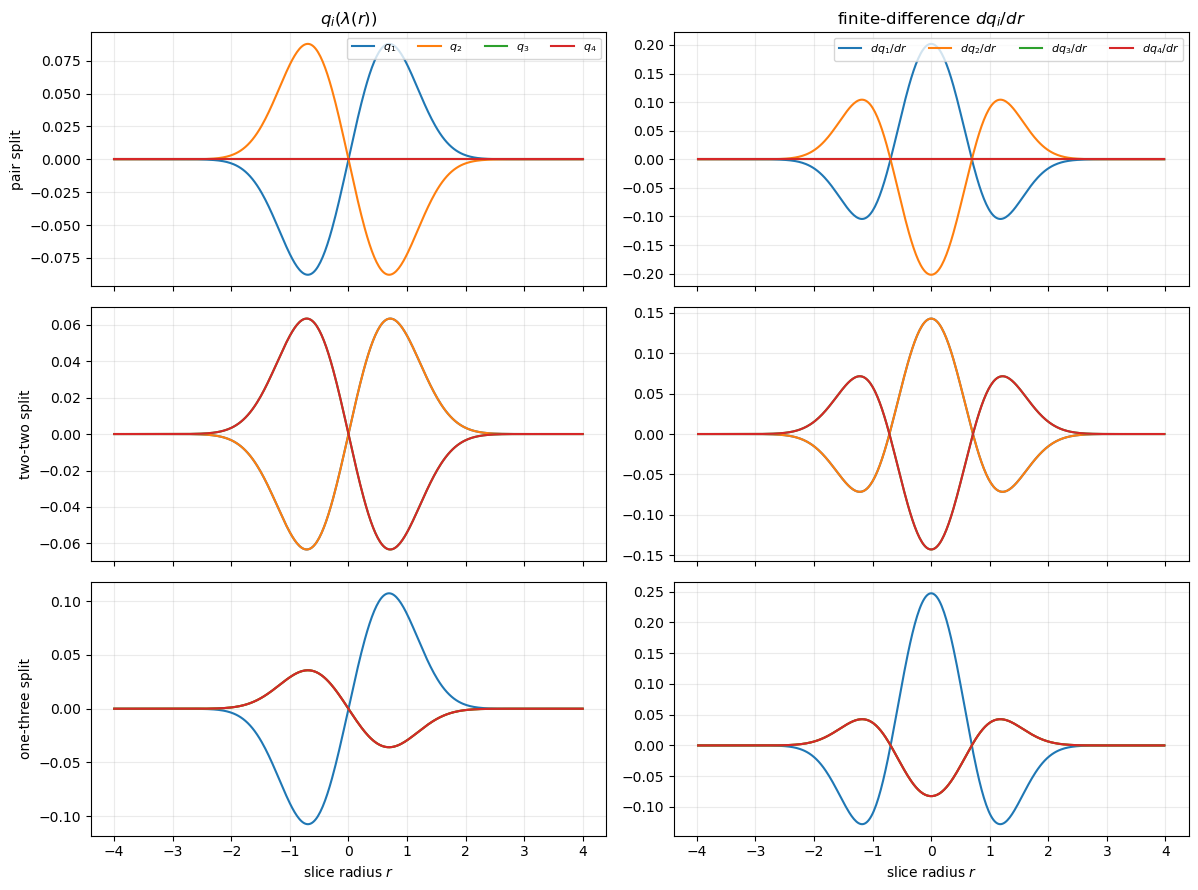

{'alpha': 1.6816117030757929,
 'cubic': 0.5338653705033293,
 'Chebyshev scale L': 3.5}

In [38]:
su4_final = sun_results["su4"]["history"][-1]
su4_alpha = su4_final["alpha"]
su4_cubic = su4_final["cubic"]
su4_scale = 3.5
su4_tail_eps = 1.0e-6

def normalize_direction(values):
    mean = sum(values) / len(values)
    centered = [value - mean for value in values]
    norm = math.sqrt(sum(value * value for value in centered))
    return [value / norm for value in centered]

def su4_conservative_action(lam):
    p2 = sum(value * value for value in lam)
    cubic_tail = sum((value * value + su4_tail_eps**2) ** 1.5 for value in lam)
    return su4_alpha * p2 + su4_cubic * cubic_tail

def su4_conservative_q(lam):
    mean = sum(lam) / len(lam)
    centered = [value - mean for value in lam]
    amplitude = math.exp(-0.5 * su4_conservative_action(centered))
    return [amplitude * value / su4_scale for value in centered]

su4_slice_directions = {
    "pair split": normalize_direction([1.0, -1.0, 0.0, 0.0]),
    "two-two split": normalize_direction([1.0, 1.0, -1.0, -1.0]),
    "one-three split": normalize_direction([3.0, -1.0, -1.0, -1.0]),
}
su4_r_values = [-4.0 + 8.0 * index / 400 for index in range(401)]

fig, axes = plt.subplots(
    len(su4_slice_directions),
    2,
    figsize=(12, 9),
    sharex=True,
)
for row, (label, direction) in enumerate(su4_slice_directions.items()):
    q_values = [
        su4_conservative_q([radius * value for value in direction])
        for radius in su4_r_values
    ]
    for component in range(4):
        component_values = [value[component] for value in q_values]
        derivative_values = [
            (component_values[index + 1] - component_values[index - 1])
            / (su4_r_values[index + 1] - su4_r_values[index - 1])
            for index in range(1, len(su4_r_values) - 1)
        ]
        axes[row, 0].plot(
            su4_r_values,
            component_values,
            label=fr"$q_{component + 1}$",
        )
        axes[row, 1].plot(
            su4_r_values[1:-1],
            derivative_values,
            label=fr"$dq_{component + 1}/dr$",
        )
    axes[row, 0].set_ylabel(label)
    axes[row, 0].grid(alpha=0.25)
    axes[row, 1].grid(alpha=0.25)

axes[0, 0].set_title(r"$q_i(\lambda(r))$")
axes[0, 1].set_title(r"finite-difference $dq_i/dr$")
axes[-1, 0].set_xlabel(r"slice radius $r$")
axes[-1, 1].set_xlabel(r"slice radius $r$")
axes[0, 0].legend(ncol=4, fontsize=8)
axes[0, 1].legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

{"alpha": su4_alpha, "cubic": su4_cubic, "Chebyshev scale L": su4_scale}


### SU(4) Conservative Baseline

The plot checks cross-grid stability of the current trusted SU(4) baseline. The Hellmann-Feynman diagnostic compares the saved central value of `Tr X^4` to a finite difference of independently trained `g \pm 0.02` runs.

### SU(4) Training Loss History

For this deterministic quadrature run, the training loss is the variational Rayleigh quotient \(E_\theta\). The first plot shows the saved energy history. The second plot shows \(\log_{10}(E_\theta-E_{\rm final})\), using a small floor only at the last point where the difference is zero by definition.

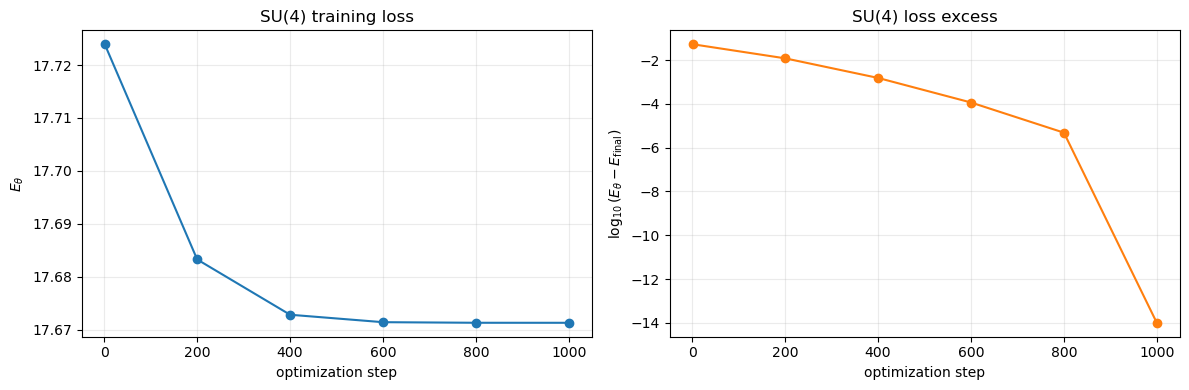

{'initial energy': 17.723923248432722,
 'final training energy': 17.671306083278612,
 'energy decrease': 0.05261716515411052,
 'saved history points': 6}

In [37]:
su4_history = sun_results["su4"]["history"]
su4_steps = [record["step"] for record in su4_history]
su4_loss = [record["energy"] for record in su4_history]
su4_loss_final = su4_loss[-1]
su4_loss_excess = [max(value - su4_loss_final, 1.0e-14) for value in su4_loss]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(su4_steps, su4_loss, marker="o")
axes[0].set_xlabel("optimization step")
axes[0].set_ylabel(r"$E_\theta$")
axes[0].set_title("SU(4) training loss")
axes[0].grid(alpha=0.25)

axes[1].plot(
    su4_steps,
    [math.log10(value) for value in su4_loss_excess],
    marker="o",
    color="tab:orange",
)
axes[1].set_xlabel("optimization step")
axes[1].set_ylabel(r"$\log_{10}(E_\theta-E_{\rm final})$")
axes[1].set_title("SU(4) loss excess")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

{
    "initial energy": su4_loss[0],
    "final training energy": su4_loss_final,
    "energy decrease": su4_loss[0] - su4_loss_final,
    "saved history points": len(su4_history),
}

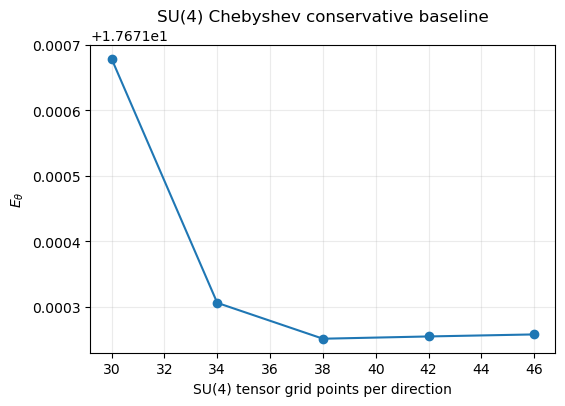

{'grid 42 energy': 17.671254775405174,
 'grid 42 virial residual': -0.0009001003488045001,
 'Hellmann-Feynman': {'delta_g': 0.02,
  'central_tr_x4': 4.8105785188834025,
  'finite_difference_derivative': 4.810702367595354,
  'error': -0.00012384871195170177}}

In [36]:
su4_evals = sun_results["su4"]["evaluations"]
su4_grids = [int(key) for key in su4_evals]
su4_energies = [su4_evals[str(grid)]["energy"] for grid in su4_grids]

plt.figure(figsize=(6, 4))
plt.plot(su4_grids, su4_energies, marker="o")
plt.xlabel("SU(4) tensor grid points per direction")
plt.ylabel(r"$E_{\theta}$")
plt.title("SU(4) Chebyshev conservative baseline")
plt.grid(alpha=0.25)
plt.show()

{
    "grid 42 energy": su4_evals["42"]["energy"],
    "grid 42 virial residual": su4_evals["42"]["virial_residual"],
    "Hellmann-Feynman": {
        key: value
        for key, value in sun_results["su4"]["hellmann_feynman"].items()
        if key not in ("minus", "plus")
    },
}